In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
data = pd.read_csv("./../data/scored_sequences/scores.csv", header=None, low_memory=False, names=['id', 'struct', 'brightness', 'sequence'])
batch_1 = pd.read_csv("./../data/scored_sequences/scores_batch1.csv", header=None, low_memory=False, names=['id', 'struct', 'brightness', 'sequence'])
batch_2 = pd.read_csv("./../data/scored_sequences/scores_batch2.csv", low_memory=False, names=['id', 'struct', 'brightness', 'sequence'])

In [25]:
print(data.shape)
print(batch_1.shape)
print(batch_2.shape)

(5409507, 4)
(2520005, 4)
(2000001, 4)


In [26]:
merged_df = pd.concat([batch_1, batch_2], axis=0, ignore_index=True)
mask = pd.to_numeric(merged_df['brightness'], errors='coerce').isna()
merged_df = merged_df[~mask]
merged_df['brightness'] = merged_df['brightness'].astype(float)

Text(0.5, 0, 'Fluorescence Intentisy')

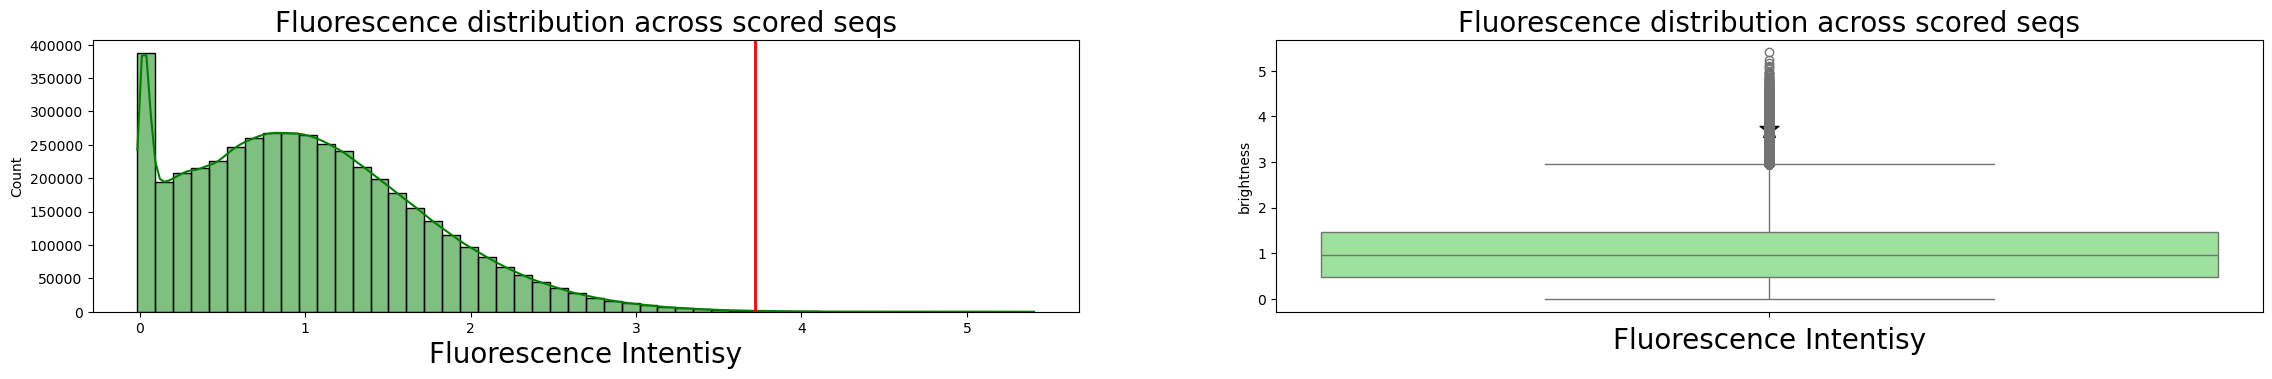

In [29]:
plt.figure(figsize=(28, 12))

WT = 3.719212 #avGFP


plt.subplot(3,2,1)
sns.histplot(merged_df["brightness"], bins=50, kde=True, color="green")
plt.axvline(WT, color="red", linestyle="-", linewidth=2)
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)

plt.subplot(3,2,2)
sns.boxplot(y=merged_df["brightness"], color="lightgreen")
plt.scatter(x=0, y=WT, color="red", marker="*", s=200, edgecolors="black")
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)

In [30]:
good = merged_df[merged_df["brightness"] >= WT]

In [37]:
good.nlargest(30, "brightness")

,id,struct,brightness,sequence
1399211,1379211,"avGFP_2WUR,",5.406,MGRDLFAGEVPVLVLMVGNVDGANFAIAGVGFGDARRGLLVLLAVA...
1875588,1855588,"EGFP_4EUL,",5.240,MGRELFEGLRPVLVVMKGSVDGKNFALVGVGVGYPKLGLRAMVVVS...
1206315,1186315,"avGFP_2WUR,",5.170,MGRDLFSGPVPVLVLMLGSVDGARFAVLGVGVGYARLGFQAILAVF...
1848763,1828763,"EGFP_4EUL,",5.100,MGSSLFEGEVPVLVLALGDVDGRRFAVAGVGVGHRREGLLVAVLVA...
1303538,1283538,"avGFP_2WUR,",5.086,MGADLLSGPVPVLVALLGDADGARFAVLGAGVGFARRGLLVLLAVN...
1837058,1817058,"EGFP_4EUL,",5.047,MGSSLLEGVVPVLILMRGNINGKKFAVAGVGAGDARRGLLALLLVS...
216017,196017,"AausFP1_6S67,",4.965,MFDQPIPLLVLALGNIDGRRFAIVGAGVGDARTGTVVAHLVSVSGE...
291651,271651,"AausFP1_6S67,",4.960,MFDKRIPLFVYMKGNIDGNKFNIVGVGYGDARTGEIIAHYVSTTGK...
4283566,1763560,"mBaoJin_8Q79,",4.953,MPLIPYVYLALGTVDGVPFALAGAGIGNPAEGFAAGVVVSVSGKLP...
1289311,1269311,"avGFP_2WUR,",4.950,MGASLFEGPVPVAVLLVGDVDGAKFAVAGAGVGDARRGLLALLLVA...


In [41]:
set(good["struct"])

{'AausFP1_6S67,',
 'EGFP_4EUL,',
 'StayGold_8ILK,',
 'amacGFP_7LG4,',
 'avGFP_2WUR,',
 'cgreGFP_2HPW,',
 'mBaoJin_8Q79,',
 'ppluGFP_2G6X,',
 'sfGFP_2B3P,'}

In [40]:
good["sequence"].iloc[0]

'MFDRPIPLVVLGVGNIDGRSFLVAGAGWGDANTGEIVAHYVSLSGELPVPWPALLPILPLAFAKWPEDIPNFERSMLPEGYYRYNVMRFEGDGTIRSLGRVYYRDGALYNVTYVIGSGFKEGGYVTGRRLELSAEPWVIQVFPAPELRGVKETATLTLPVKGGGSVRMDVEGITFPLGEGEVEIPEPHGVYVEARLYRDPSVAADHLHVKARMEAINFRRELR'

Text(0.5, 0, 'Fluorescence Intentisy')

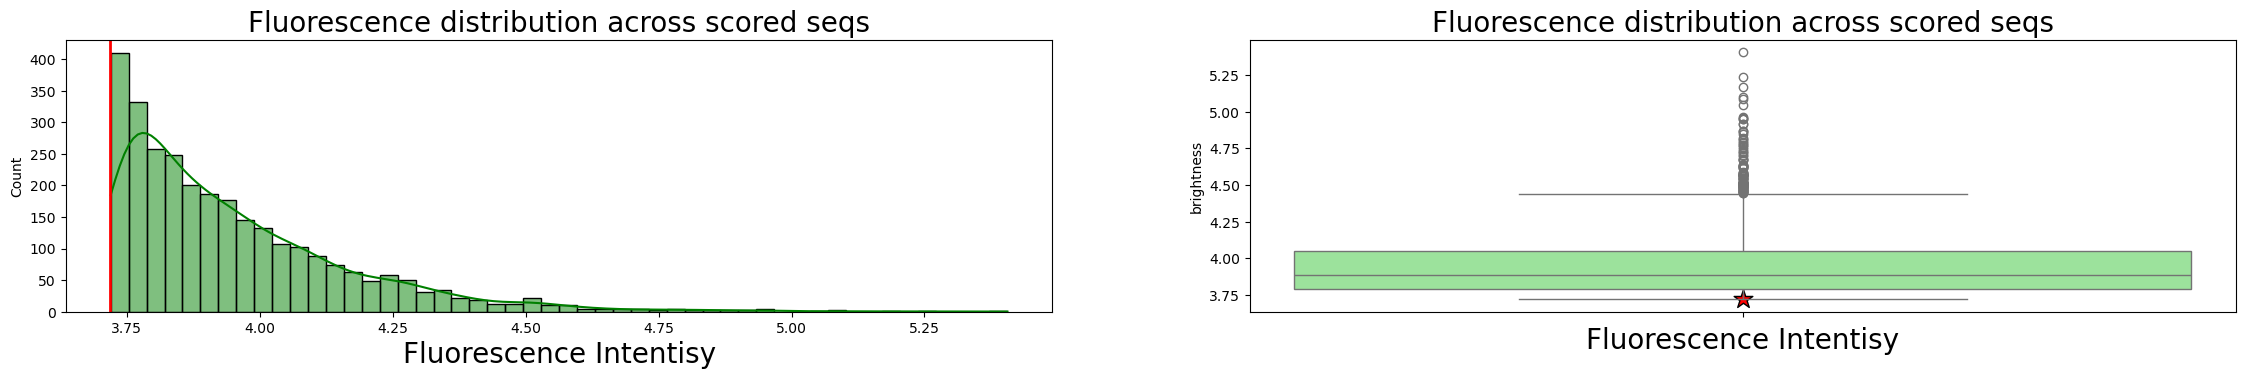

In [35]:
plt.figure(figsize=(28, 12))

WT = 3.719212 #avGFP


plt.subplot(3,2,1)
sns.histplot(good["brightness"], bins=50, kde=True, color="green")
plt.axvline(WT, color="red", linestyle="-", linewidth=2)
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)

plt.subplot(3,2,2)
sns.boxplot(y=good["brightness"], color="lightgreen")
plt.scatter(x=0, y=WT, color="red", marker="*", s=200, edgecolors="black")
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)

In [28]:
batch_2

,id,struct,brightness,sequence
0,0,"ppluGFP_2G6X,",3.90600,AMEIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALTFS...
1,1,"ppluGFP_2G6X,",0.40770,GISISVSVSGTINGTPFSLTGGGSGNPTQGVYTVSATSTTGPLPVN...
2,2,"ppluGFP_2G6X,",1.38200,MIKIEVEIEGTINGTPFKLAGGGEGDPEKGVYTVSAKSLLGPLPVN...
3,3,"ppluGFP_2G6X,",1.63600,MISIEVTVTGTINGVPFRLVGGGEGDPSKGVYTVSARSLTGPLPFN...
4,4,"ppluGFP_2G6X,",1.76600,MIEIEVSVSGTINGTSFSLKGGGEGDPEKGIYTVTATSTTGPLPVN...
...,...,...,...,...
1999995,1999995,"mBaoJin_8Q79,",0.00439,MSEKPFVFSAVGTVDGKPFALVGAGSGDPSKGYYRGVVISASGALP...
1999996,1999996,"mBaoJin_8Q79,",2.01400,MEYVPYLFASLGSVNGVPFALAGAGVGNPSKGVYAGVVVSVSGSAP...
1999997,1999997,"mBaoJin_8Q79,",1.91900,MPLVPFRFSAEGTVNGVPFRLVGAGAGDPKRGFYAGLVVSASGEFP...
1999998,1999998,"mBaoJin_8Q79,",0.96900,MRFKPWLFLALGSVDGRGFALVGAGVGDPSLGIYAGVVVSASGRLP...


In [25]:
data

,0,1,2,3
0,0,"ppluGFP_2G6X,",3.901016,AMEIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALTFS...
1,1,"ppluGFP_2G6X,",1.871401,MVKVRIRVEGTINGKPFKLEGGGTGDPAKGTLTVTATSTLGPLPVN...
2,2,"ppluGFP_2G6X,",1.371895,MIELDIEIEGTINGVPFKLVGGGTGDPEKGEFTAEAESTLGDLPFN...
3,3,"ppluGFP_2G6X,",1.364225,MIRITIEVTGTINGQPFRLVGGGTGDPEKGEFTVEAESTTGPLPFN...
4,4,"ppluGFP_2G6X,",3.054842,MVRLRLRVRGTINGVPFELEGGGEADPARGEFTVRATSTLGPLPFN...
...,...,...,...,...
5409502,3500002,"TGP_4TZA,",2.016000,SVIPEEVRVEYRMRGSLNGHPFEIRGRGVGEPHKGTEVLDLELVRG...
5409503,3500003,"TGP_4TZA,",2.342000,GVIPERVRVEGVMEGSINGHKFKIRGRGEGRPHEGTSVLELEVVEG...
5409504,3500004,"TGP_4TZA,",2.955000,SVIPERMKVEQVLEGRINGHAFRITAEGEGYPYEGRDVLHLVLTEG...
5409505,3500005,"TGP_4TZA,",1.651000,SVIPEKVKVEGVMEGSINGHKFKIKYEGEGEPYKGKEVLKLELVEG...


In [26]:
batch_1

,0,1,2,3
0,0,"AausFP1_6S67,",3.105,LFREKIPYVVEMEGDVEGMKFSVRGKGHGDANTGKIEASFICTTGE...
1,1,"AausFP1_6S67,",1.106,MFDKPIPLEVDMEGNVEGKNFKVKGKGVGDSKTGEIKMHLVSETGK...
2,2,"AausFP1_6S67,",1.696,MFDEPIPLRVDMEGEIDGKRFKVRGVGYGDAKTGTIVALYIATSGE...
3,3,"AausFP1_6S67,",1.055,MFDEPLPLLVLMRGNIEGRKFAVVGAGVGDARTGRIEAHFVAVTGE...
4,4,"AausFP1_6S67,",2.426,MFDKPIPLLVLAYGNVDGSRFAVVGVGVCDARTGLIVALLVAASGE...
...,...,...,...,...
1809995,1789995,"EGFP_4EUL,",0.995,MGSSLLEGPVPILVLARGNVDGKKFAVLGVGVGYAPKGLVVAHFVA...
1809996,1789996,"EGFP_4EUL,",3.111,MGSELLRGRVPVFNLLLGNVDGKNFAILGVGFGDARRGLLVAYFVS...
1809997,1789997,"EGFP_4EUL,",3.281,MGLELFRGTVPVLTLALGNVDGKSFAIAGAGLGLAPLGLVAALYVS...
1809998,1789998,"EGFP_4EUL,",1.744,MGRELFEGEVPVLVLVGGNVDGKRFAIAGVGWGNAKKGELRLHLVA...


In [27]:
batch_2

,id,struct,brightness,sequence
0,0,"ppluGFP_2G6X,",3.9060,AMEIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALTFS...
1,1,"ppluGFP_2G6X,",0.4077,GISISVSVSGTINGTPFSLTGGGSGNPTQGVYTVSATSTTGPLPVN...
2,2,"ppluGFP_2G6X,",1.3820,MIKIEVEIEGTINGTPFKLAGGGEGDPEKGVYTVSAKSLLGPLPVN...
3,3,"ppluGFP_2G6X,",1.6360,MISIEVTVTGTINGVPFRLVGGGEGDPSKGVYTVSARSLTGPLPFN...
4,4,"ppluGFP_2G6X,",1.7660,MIEIEVSVSGTINGTSFSLKGGGEGDPEKGIYTVTATSTTGPLPVN...
...,...,...,...,...
1799995,1799995,"mBaoJin_8Q79,",1.9030,MKLKPWLFAAVGRVNGEPFALAGGGAGSPEEGVYAGVVVAVSGELP...
1799996,1799996,"mBaoJin_8Q79,",1.5450,MLLTPFVFSMNGTVNGTSFSLTGAGAGSPSLGLFAGLVISTSGKLP...
1799997,1799997,"mBaoJin_8Q79,",1.8140,METKPFLFLAVGTVDGTPFALVGAGVGNPKEGWYAGVVVFASGTAP...
1799998,1799998,"mBaoJin_8Q79,",0.3135,MPWKPFAFAAVGTVNGTPFALVGAGAGNPSEGIYAGVVVSASGALP...


In [28]:
data.nlargest(20, 2)

,0,1,2,3
2615564,706064,"AausFP1_6S67,",4.530000,LFAERFPVRVQLDGDIEGKRFRVEGEGWGDANTGEVELRFVCTTGE...
3804422,1894922,"avGFP_2WUR,",4.380000,SGADLLKGVVPLEIRMTGDFNGKKFEIVGRGEADATRGYQELHFVC...
2828239,918739,"AausFP1_6S67,",4.332000,LFAEPFPLRVELEGDVEGKKFRITGEGTGDARTGRVRLRFVCTTGE...
2854430,944930,"AausFP1_6S67,",4.316000,LFEEPFPVKVHLTLNVEGQQAEIEGEGTGDARTGEVELRYVCTTGE...
226171,226171,"ppluGFP_2G6X,",4.311273,MVRVEIRIEGTVNGVPFRLEGGGEGVPERGELTVTVRSTLGPLPFN...
4075593,2166093,"EGFP_4EUL,",4.305000,NGADLFRGVVPVRVRMEGDVNGKRFTVEGEGEVDATRGRIRMKYTC...
3604368,1694868,"avGFP_2WUR,",4.290000,SGADLFAGPVPLRTFFEGDVNGKKFTIEGEGVGLATEGTQEQTYVC...
3875154,1965654,"avGFP_2WUR,",4.285000,TGADLLAGPVPVRVRMKGDFNGKKFEIVGEGTMDARRGRQEQYYVC...
2119952,210452,"vsfGFP-0_4PFE,",4.258000,EEGRALLAEPVPVKVHLKYDVNGKKGEIVGEGVGDARTGKQEQLYV...
3113172,1203672,"amacGFP_7LG4,",4.210000,YKYSEGQKLLEGEVPVRINLGGRVAGRDFTIVGEGVMNAAEGTLKV...


In [29]:
batch_1.nlargest(20, 2)

,0,1,2,3
1399211,1379211,"avGFP_2WUR,",5.406,MGRDLFAGEVPVLVLMVGNVDGANFAIAGVGFGDARRGLLVLLAVA...
1206315,1186315,"avGFP_2WUR,",5.170,MGRDLFSGPVPVLVLMLGSVDGARFAVLGVGVGYARLGFQAILAVF...
1303538,1283538,"avGFP_2WUR,",5.086,MGADLLSGPVPVLVALLGDADGARFAVLGAGVGFARRGLLVLLAVN...
216017,196017,"AausFP1_6S67,",4.965,MFDQPIPLLVLALGNIDGRRFAIVGAGVGDARTGTVVAHLVSVSGE...
291651,271651,"AausFP1_6S67,",4.960,MFDKRIPLFVYMKGNIDGNKFNIVGVGYGDARTGEIIAHYVSTTGK...
1289311,1269311,"avGFP_2WUR,",4.950,MGASLFEGPVPVAVLLVGDVDGAKFAVAGAGVGDARRGLLALLLVA...
1403780,1383780,"avGFP_2WUR,",4.914,MGRDLFTGLVPVLVLMYGNVDGKKFAVAGVGVGNARKGTLALLLIS...
1748698,1728698,"EGFP_4EUL,",4.914,MGSSLFEGLVPVAVLLLGNVDGANFAVAGAGVGYARRGLLLLHLEA...
1144946,1124946,"avGFP_2WUR,",4.870,MGRDLFSGLVPVLILLYGNFDGEKFAVLGVGVAHARRGLAVVLLVA...
1481613,1461613,"avGFP_2WUR,",4.860,MGSELFRGVVPVAVLALGEVDGKKFALAGVGACDARRGLLLLLVVS...


In [31]:
batch_2.nlargest(20, "brightness")

,id,struct,brightness,sequence
1763560,1763560,"mBaoJin_8Q79,",4.953,MPLIPYVYLALGTVDGVPFALAGAGIGNPAEGFAAGVVVSVSGKLP...
1329076,1329076,"sfGFP_2B3P,",4.617,GRGEELLEGLVPVLVLLVGNFDGKNFAVAGVGVGNAARGELRLLLV...
1718730,1718730,"mBaoJin_8Q79,",4.580,MPLKPFIYAMLGTVDGVPFGLAGAGVGNPAEGIFAGLVVSITGSFP...
734235,734235,"StayGold_8ILK,",4.540,MSLKPYLFLALGTVDGKPFALAGAGAGNPDLGVYAGVVVSVSGALP...
642880,642880,"StayGold_8ILK,",4.520,MALTPFLFAMAGSVDGTPFALAGAGAGDPSLGVYAGVVVAVSGTAP...
1727375,1727375,"mBaoJin_8Q79,",4.516,METKPWLFAALGSVNGVPFALVGAGFGNPKEGWFAGVVISASGALP...
965309,965309,"StayGold_8ILK,",4.492,MSLTPYLLFALGTVDGTPFALAGGGVGNPSLGFYAGVVVSVTGEFP...
818856,818856,"StayGold_8ILK,",4.465,ASLKPYLFGAIGTVNGTPFTLTGAGAGNPAEGWYSGTVVATSGTLP...
1765892,1765892,"mBaoJin_8Q79,",4.453,MPLRPYLFAAAGRVNGTPFSLVGAGFGDPSLGVYAGVVVSASGELP...
748077,748077,"StayGold_8ILK,",4.418,MSLTPYVFAALGTVNGTPFALAGAGAGNPALGEFAGVVVFVSGTAP...


array(['ppluGFP_2G6X,', 'StayGold_8ILK,', 'sfGFP_2B3P,', 'mBaoJin_8Q79,',
       'vsfGFP-0_4PFE,', 'AausFP1_6S67,'], dtype=object)

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

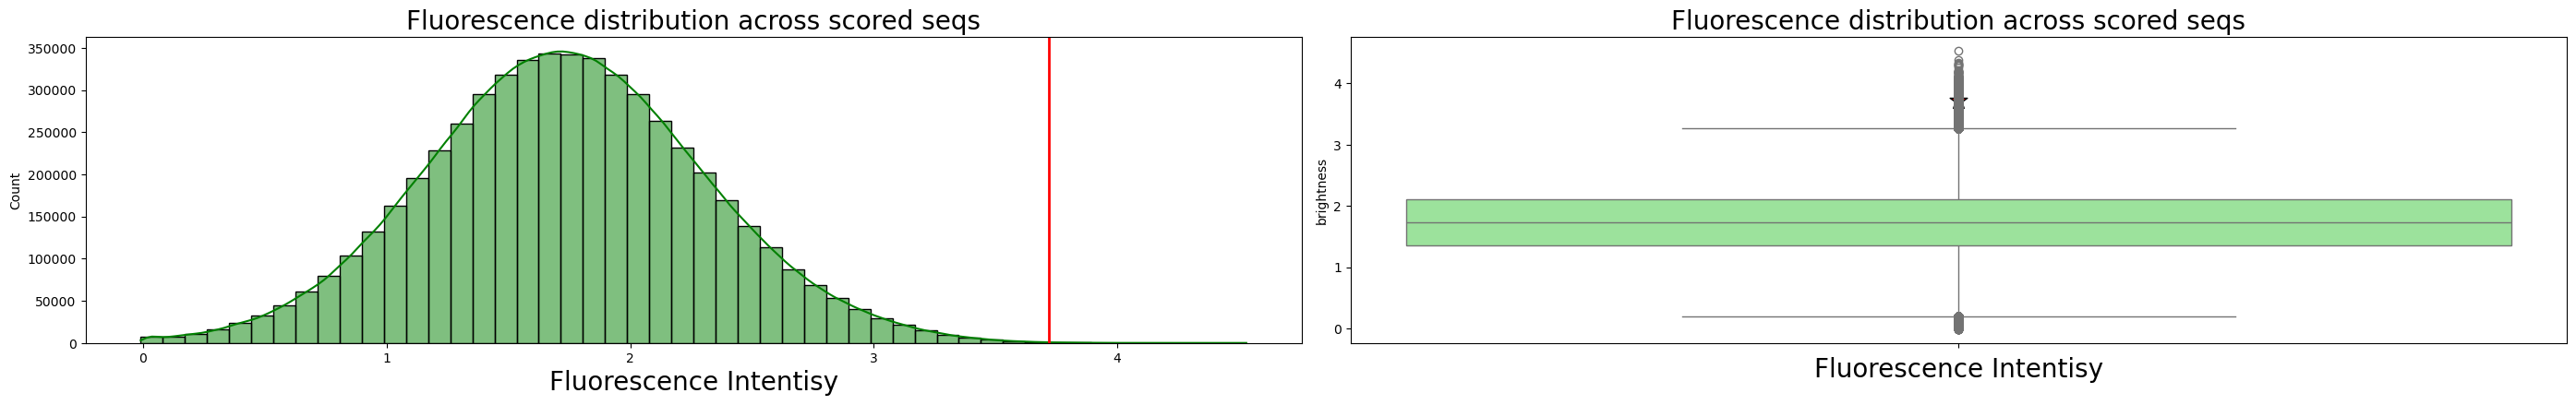

In [34]:
plt.figure(figsize=(28, 12))

WT = 3.719212 #avGFP


plt.subplot(3,2,1)
sns.histplot(data["brightness"], bins=50, kde=True, color="green")
plt.axvline(WT, color="red", linestyle="-", linewidth=2)
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)

plt.subplot(3,2,2)
sns.boxplot(y=data["brightness"], color="lightgreen")
plt.scatter(x=0, y=WT, color="red", marker="*", s=200, edgecolors="black")
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)




# plt.subplot(3,2,3)
# sns.histplot(batch_1[2], bins=50, kde=True, color="cyan")
# plt.axvline(WT, color="red", linestyle="-", linewidth=2)
# plt.title("Fluorescence distribution across scored seqs", fontsize=20)
# plt.xlabel("Fluorescence Intentisy", fontsize=20)

# plt.subplot(3,2,4)
# sns.boxplot(y=batch_1[2], color="lightcyan")
# plt.scatter(x=0, y=WT, color="red", marker="*", s=200, edgecolors="black")
# plt.title("Fluorescence distribution across scored seqs", fontsize=20)
# plt.xlabel("Fluorescence Intentisy", fontsize=20)




# plt.subplot(3,2,5)
# sns.histplot(batch_2["brightness"], bins=50, kde=True, color="magenta")
# plt.axvline(WT, color="red", linestyle="-", linewidth=2)
# plt.title("Fluorescence distribution across scored seqs", fontsize=20)
# plt.xlabel("Fluorescence Intentisy", fontsize=20)

# plt.subplot(3,2,6)
# sns.boxplot(y=batch_2["brightness"], color="magenta")
# plt.scatter(x=0, y=WT, color="red", marker="*", s=200, edgecolors="black")
# plt.title("Fluorescence distribution across scored seqs", fontsize=20)
# plt.xlabel("Fluorescence Intentisy", fontsize=20)



plt.tight_layout()
plt.show()

In [39]:
print("Среднее:", data[2].mean())
print("Медиана:", data[2].median())
print("Стд. откл.:", data[2].std())
print("Минимум:", data[2].min())
print("Максимум:", data[2].max())
print()
print()
print()
print("Среднее:", batch_1[2].mean())
print("Медиана:", batch_1[2].median())
print("Стд. откл.:", batch_1[2].std())
print("Минимум:", batch_1[2].min())
print("Максимум:", batch_1[2].max())
print()
print()
print()
print("Среднее:", batch_2["brightness"].mean())
print("Медиана:", batch_2["brightness"].median())
print("Стд. откл.:", batch_2["brightness"].std())
print("Минимум:", batch_2["brightness"].min())
print("Максимум:", batch_2["brightness"].max())

Среднее: 1.7333324352815793
Медиана: 1.728
Стд. откл.: 0.5738230188879344
Минимум: -0.010043467
Максимум: 4.53



Среднее: 0.9934584513473204
Медиана: 0.922
Стд. откл.: 0.6878797047335825
Минимум: -0.01483
Максимум: 5.406



Среднее: 1.0857848313100888
Медиана: 1.029
Стд. откл.: 0.707985765302969
Минимум: -0.01496
Максимум: 4.953


In [40]:
origs = pd.read_csv("./../data/data.csv")
exclusions = pd.read_csv("./../data/Exclusion_List.csv")

In [41]:
forbidden = pd.concat([origs["seq"], exclusions["Sequence"]], ignore_index=True)

In [74]:
# Отбор элементов из s1, которых нет в s2
result = s1[~s1.isin(s2)]

<class 'pandas.core.series.Series'>


In [42]:
data[3].shape

(5409507,)

In [44]:
selected = data[3][~data[3].isin(forbidden)]
selected_1 = batch_1[3][~batch_1[3].isin(forbidden)]
selected_2 = batch_2["sequence"][~batch_2["sequence"].isin(forbidden)]

In [46]:
print(len(selected))
print(len(selected_1))
print(len(selected_2))

5409507
1810000
1800000


In [47]:
great = data[data[2] >= WT]
great_1 = batch_1[batch_1[2] >= WT]
great_2 = batch_2[batch_2["brightness"] >= WT]

In [48]:
great

,0,1,2,3
0,0,"ppluGFP_2G6X,",3.901016,AMEIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALTFS...
22700,22700,"ppluGFP_2G6X,",3.807578,MIKLEVRIEGTINGVPFRLEGGGEGDPEKGVFTVRARSTLGPLPFN...
44467,44467,"ppluGFP_2G6X,",3.754389,MVEIEVRVEGTVNGVPFRLEGGGTGDPAAGELTVRARSTLGELPFN...
79881,79881,"ppluGFP_2G6X,",3.748578,MVEIDIVVEGTVNGVPFKLEGGGVGDPEKGEYTVTATSTLGPLPVN...
98612,98612,"ppluGFP_2G6X,",3.748371,MLRIEVEVRGTVNGVPFALRGGGEGDPEAGRLTVTAESTLGELPFN...
...,...,...,...,...
5364281,3454781,"TGP_4TZA,",3.734000,GVIPERVRVEGRMRGAINGHEFEIEFEGEGRPHEGRERLELTLVRG...
5367965,3458465,"TGP_4TZA,",3.760000,SVIPDTMRVEGRMVGSVNGHPFEITFEGVGKPYEGTDVMHCTLTAG...
5378975,3469475,"TGP_4TZA,",3.965000,MVIPREMRLRGVMEGSINGHEFRIEFEGVGRPYEGTSVSTLRLVEG...
5403092,3493592,"TGP_4TZA,",3.756000,MVIPERMRVRLRLRGSINGHPFVIEGEGVGEPYRGRSVLELTVTEG...


In [49]:
great_1

,0,1,2,3
896,896,"AausFP1_6S67,",3.727,MFDRPIPLVVLGVGNIDGRSFLVAGAGWGDANTGEIVAHYVSLSGE...
1766,1766,"AausFP1_6S67,",4.242,MFDKTIPLFTLMYGDVEGRRFAVVGAGVGDANTGEIEAHYLSVTGE...
2099,2099,"AausFP1_6S67,",3.920,MFDRPLPLLVLMEGDVEGRRFRVAGAGVGDARTGLVAALFVSLSGE...
2766,2766,"AausFP1_6S67,",3.787,MFDEPLPLRTLGYGNVDGARFAVAGAGVGDARTGRIRATYISLTGA...
3964,3964,"AausFP1_6S67,",4.082,MFDRPIPLVVLGRGEIDGRKFAVAGAGVGDANTGLIEAHFVALTGE...
...,...,...,...,...
1806146,1786146,"EGFP_4EUL,",3.771,MGSELFKDWVPVLVLLLGNVDGERFAVGGVGFGNAPKGEIVLHLVS...
1808935,1788935,"EGFP_4EUL,",3.918,MGSELFEGLVPVLVLLVGNVDGKNFAVLGVGVGDARKGLLAGHYVS...
1808959,1788959,"EGFP_4EUL,",3.850,MGSELLEGPVPVLVGMVGNVDGKNFSIVGAGVCLARRGLLALLLVS...
1809561,1789561,"EGFP_4EUL,",4.000,MGSSLFEGVVPVLVSLEGNVDGLNFSVLGVGAGWARKGLAIMDAYS...


In [50]:
great_2

,id,struct,brightness,sequence
0,0,"ppluGFP_2G6X,",3.906,AMEIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALTFS...
35114,35114,"ppluGFP_2G6X,",4.098,MIKLEVRVEGTFNGVPFRLEGGGEGDPEKGVYTVSARSLLGPLPFN...
67721,67721,"ppluGFP_2G6X,",3.742,AISIEVRVSGKIDGKPFELEGGGEGNPAAGTYTVTAVSKTGPLPVN...
119140,119140,"ppluGFP_2G6X,",3.730,MIKIEVKIEGTINGTPFSLVGGGEGNPEEGVYTVSATSTLGPLPFN...
141233,141233,"ppluGFP_2G6X,",3.720,MIEVEVKITGTINGVPFSLVGGGEGDPSRGVYTVSLKSTTGPLPFN...
...,...,...,...,...
1798001,1798001,"mBaoJin_8Q79,",3.930,MPFTPYLLALLGTVDGVPFALVGGGVGNPALGVYAGVVVSASGPAP...
1798242,1798242,"mBaoJin_8Q79,",3.826,MPLRPWLFLALGTVNGTPFALVGAGVGSPAEGFFAGVVVSASGKLP...
1798396,1798396,"mBaoJin_8Q79,",3.955,MELKPWLFSMNGTVNGTKFSLSGGGVGNPAEGFYAGVVYSTSGTLP...
1798913,1798913,"mBaoJin_8Q79,",4.035,MPLRPYRFAALGRVNGRGFALAGAGAGDPSLGFYAGVVVAVSGRAP...


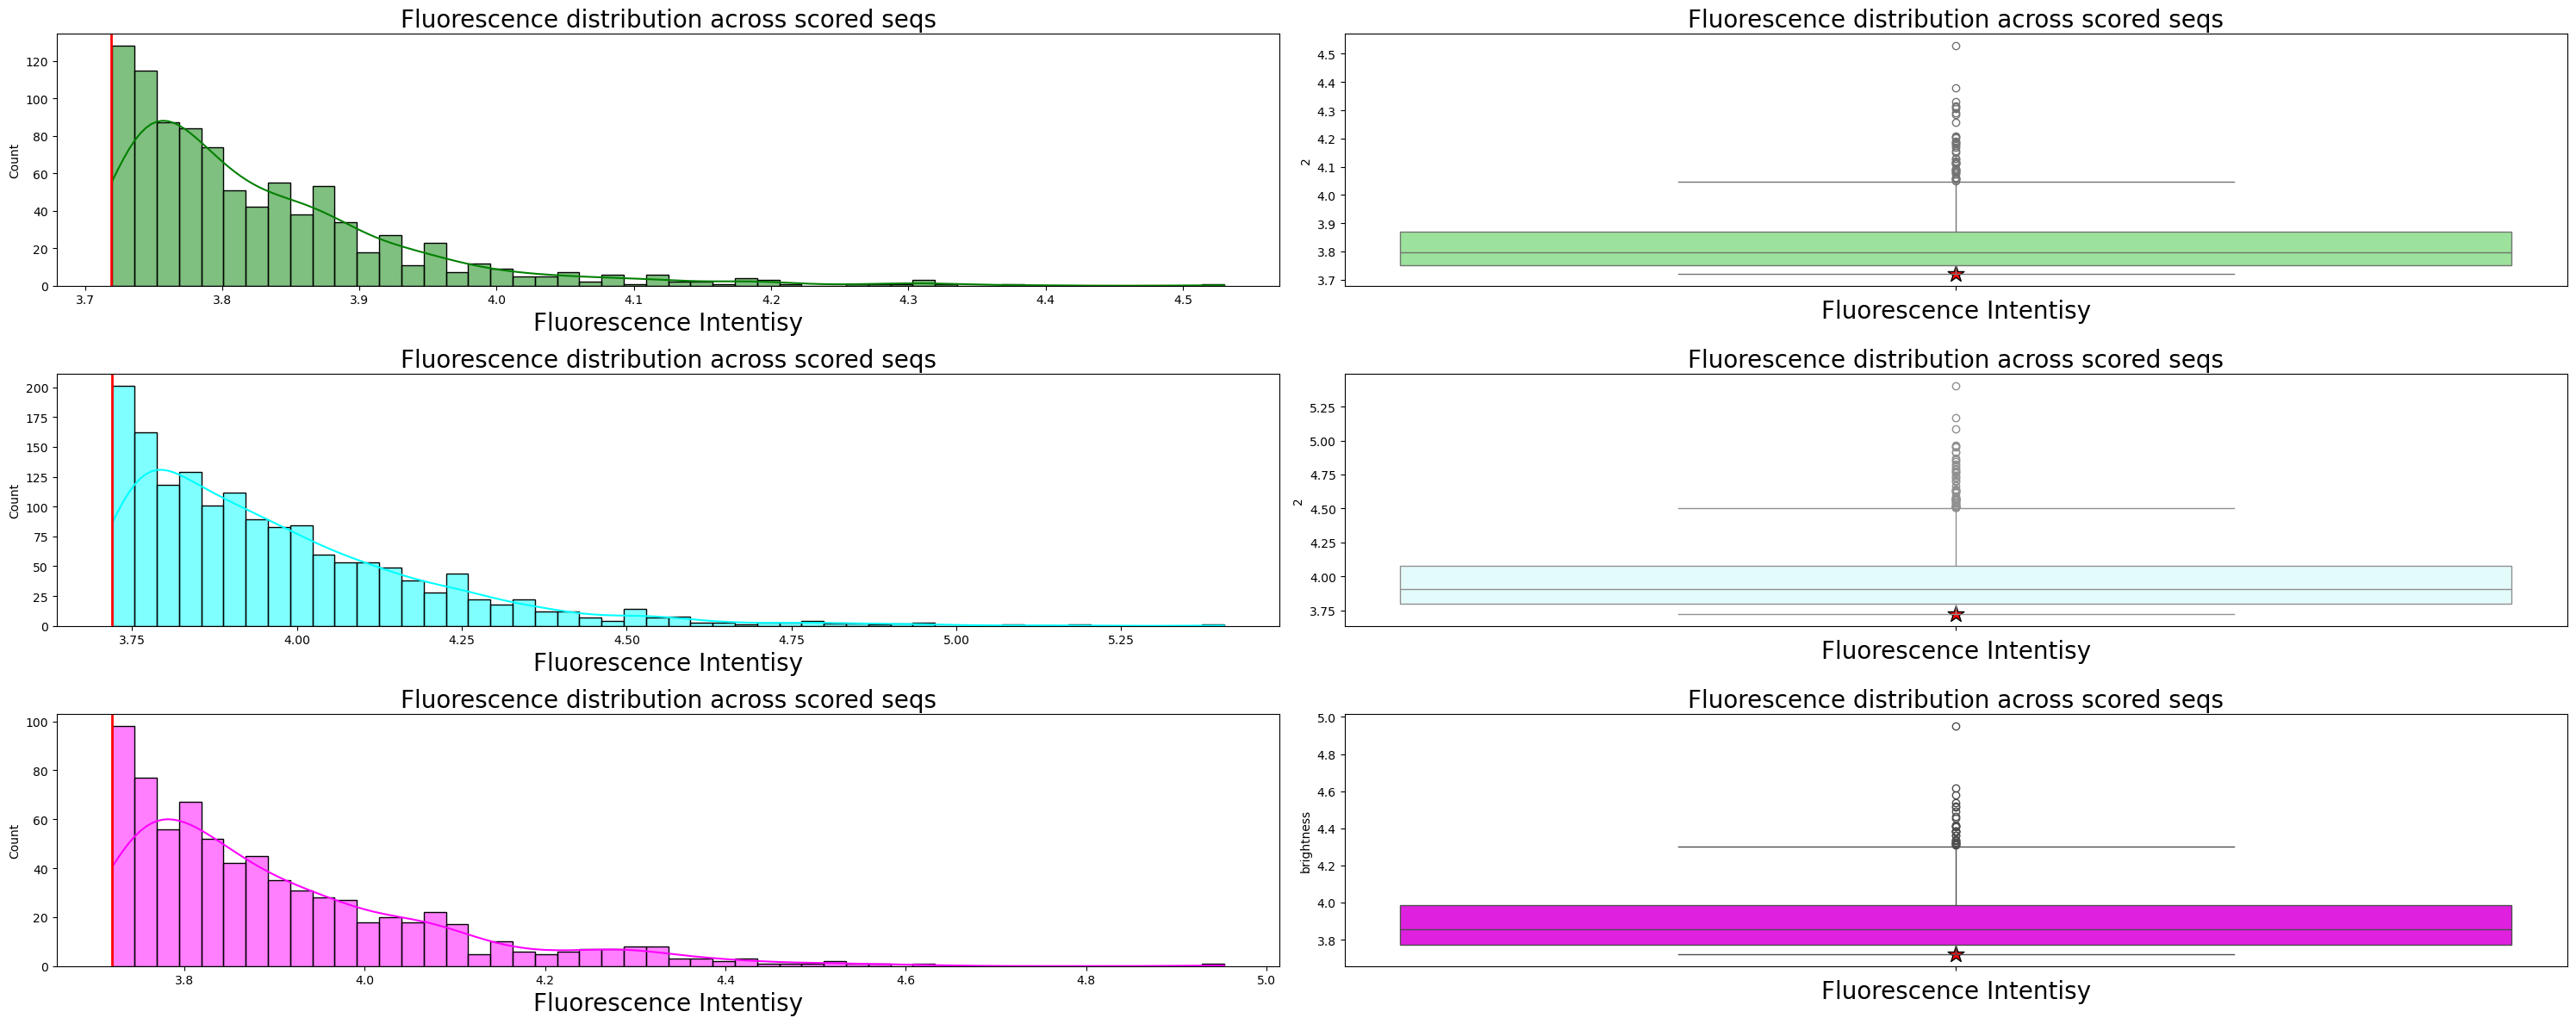

In [51]:
plt.figure(figsize=(30, 12))

WT = 3.719212 #avGFP


plt.subplot(3,2,1)
sns.histplot(great[2], bins=50, kde=True, color="green")
plt.axvline(WT, color="red", linestyle="-", linewidth=2)
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)

plt.subplot(3,2,2)
sns.boxplot(y=great[2], color="lightgreen")
plt.scatter(x=0, y=WT, color="red", marker="*", s=200, edgecolors="black")
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)




plt.subplot(3,2,3)
sns.histplot(great_1[2], bins=50, kde=True, color="cyan")
plt.axvline(WT, color="red", linestyle="-", linewidth=2)
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)

plt.subplot(3,2,4)
sns.boxplot(y=great_1[2], color="lightcyan")
plt.scatter(x=0, y=WT, color="red", marker="*", s=200, edgecolors="black")
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)




plt.subplot(3,2,5)
sns.histplot(great_2["brightness"], bins=50, kde=True, color="magenta")
plt.axvline(WT, color="red", linestyle="-", linewidth=2)
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)

plt.subplot(3,2,6)
sns.boxplot(y=great_2["brightness"], color="magenta")
plt.scatter(x=0, y=WT, color="red", marker="*", s=200, edgecolors="black")
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)



plt.tight_layout()
plt.show()

In [53]:
print("Среднее:", great[2].mean())
print("Медиана:", great[2].median())
print("Стд. откл.:", great[2].std())
print("Минимум:", great[2].min())
print("Максимум:", great[2].max())
print()
print()
print()
print("Среднее:", great_1[2].mean())
print("Медиана:", great_1[2].median())
print("Стд. откл.:", great_1[2].std())
print("Минимум:", great_1[2].min())
print("Максимум:",great_1[2].max())
print()
print()
print()
print("Среднее:", great_2["brightness"].mean())
print("Медиана:", great_2["brightness"].median())
print("Стд. откл.:",great_2["brightness"].std())
print("Минимум:",great_2["brightness"].min())
print("Максимум:",great_2["brightness"].max())

Среднее: 3.8274910656182213
Медиана: 3.7955384
Стд. откл.: 0.1064224627794526
Минимум: 3.72
Максимум: 4.53



Среднее: 3.968352564102564
Медиана: 3.908
Стд. откл.: 0.22728964728968554
Минимум: 3.72
Максимум: 5.406



Среднее: 3.9050680272108846
Медиана: 3.854
Стд. откл.: 0.17533156056151608
Минимум: 3.72
Максимум: 4.953


In [54]:
great.nlargest(20, 2)

,0,1,2,3
2615564,706064,"AausFP1_6S67,",4.530000,LFAERFPVRVQLDGDIEGKRFRVEGEGWGDANTGEVELRFVCTTGE...
3804422,1894922,"avGFP_2WUR,",4.380000,SGADLLKGVVPLEIRMTGDFNGKKFEIVGRGEADATRGYQELHFVC...
2828239,918739,"AausFP1_6S67,",4.332000,LFAEPFPLRVELEGDVEGKKFRITGEGTGDARTGRVRLRFVCTTGE...
2854430,944930,"AausFP1_6S67,",4.316000,LFEEPFPVKVHLTLNVEGQQAEIEGEGTGDARTGEVELRYVCTTGE...
226171,226171,"ppluGFP_2G6X,",4.311273,MVRVEIRIEGTVNGVPFRLEGGGEGVPERGELTVTVRSTLGPLPFN...
4075593,2166093,"EGFP_4EUL,",4.305000,NGADLFRGVVPVRVRMEGDVNGKRFTVEGEGEVDATRGRIRMKYTC...
3604368,1694868,"avGFP_2WUR,",4.290000,SGADLFAGPVPLRTFFEGDVNGKKFTIEGEGVGLATEGTQEQTYVC...
3875154,1965654,"avGFP_2WUR,",4.285000,TGADLLAGPVPVRVRMKGDFNGKKFEIVGEGTMDARRGRQEQYYVC...
2119952,210452,"vsfGFP-0_4PFE,",4.258000,EEGRALLAEPVPVKVHLKYDVNGKKGEIVGEGVGDARTGKQEQLYV...
3113172,1203672,"amacGFP_7LG4,",4.210000,YKYSEGQKLLEGEVPVRINLGGRVAGRDFTIVGEGVMNAAEGTLKV...


In [55]:
great_1.nlargest(20, 2)

,0,1,2,3
1399211,1379211,"avGFP_2WUR,",5.406,MGRDLFAGEVPVLVLMVGNVDGANFAIAGVGFGDARRGLLVLLAVA...
1206315,1186315,"avGFP_2WUR,",5.170,MGRDLFSGPVPVLVLMLGSVDGARFAVLGVGVGYARLGFQAILAVF...
1303538,1283538,"avGFP_2WUR,",5.086,MGADLLSGPVPVLVALLGDADGARFAVLGAGVGFARRGLLVLLAVN...
216017,196017,"AausFP1_6S67,",4.965,MFDQPIPLLVLALGNIDGRRFAIVGAGVGDARTGTVVAHLVSVSGE...
291651,271651,"AausFP1_6S67,",4.960,MFDKRIPLFVYMKGNIDGNKFNIVGVGYGDARTGEIIAHYVSTTGK...
1289311,1269311,"avGFP_2WUR,",4.950,MGASLFEGPVPVAVLLVGDVDGAKFAVAGAGVGDARRGLLALLLVA...
1403780,1383780,"avGFP_2WUR,",4.914,MGRDLFTGLVPVLVLMYGNVDGKKFAVAGVGVGNARKGTLALLLIS...
1748698,1728698,"EGFP_4EUL,",4.914,MGSSLFEGLVPVAVLLLGNVDGANFAVAGAGVGYARRGLLLLHLEA...
1144946,1124946,"avGFP_2WUR,",4.870,MGRDLFSGLVPVLILLYGNFDGEKFAVLGVGVAHARRGLAVVLLVA...
1481613,1461613,"avGFP_2WUR,",4.860,MGSELFRGVVPVAVLALGEVDGKKFALAGVGACDARRGLLLLLVVS...


In [56]:
great_2.nlargest(20, "brightness")

,id,struct,brightness,sequence
1763560,1763560,"mBaoJin_8Q79,",4.953,MPLIPYVYLALGTVDGVPFALAGAGIGNPAEGFAAGVVVSVSGKLP...
1329076,1329076,"sfGFP_2B3P,",4.617,GRGEELLEGLVPVLVLLVGNFDGKNFAVAGVGVGNAARGELRLLLV...
1718730,1718730,"mBaoJin_8Q79,",4.580,MPLKPFIYAMLGTVDGVPFGLAGAGVGNPAEGIFAGLVVSITGSFP...
734235,734235,"StayGold_8ILK,",4.540,MSLKPYLFLALGTVDGKPFALAGAGAGNPDLGVYAGVVVSVSGALP...
642880,642880,"StayGold_8ILK,",4.520,MALTPFLFAMAGSVDGTPFALAGAGAGDPSLGVYAGVVVAVSGTAP...
1727375,1727375,"mBaoJin_8Q79,",4.516,METKPWLFAALGSVNGVPFALVGAGFGNPKEGWFAGVVISASGALP...
965309,965309,"StayGold_8ILK,",4.492,MSLTPYLLFALGTVDGTPFALAGGGVGNPSLGFYAGVVVSVTGEFP...
818856,818856,"StayGold_8ILK,",4.465,ASLKPYLFGAIGTVNGTPFTLTGAGAGNPAEGWYSGTVVATSGTLP...
1765892,1765892,"mBaoJin_8Q79,",4.453,MPLRPYLFAAAGRVNGTPFSLVGAGFGDPSLGVYAGVVVSASGELP...
748077,748077,"StayGold_8ILK,",4.418,MSLTPYVFAALGTVNGTPFALAGAGAGNPALGEFAGVVVFVSGTAP...


In [57]:
origs.iloc[0]["seq"]

'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'

In [13]:
thermo = pd.read_csv("./../data/scored_sequences/therm_scores.csv")

In [14]:
thermo

,Unnamed: 0,id,struct,brightness,sequence,therm
0,6808718,1379211,"avGFP_2WUR,",5.406,MGRDLFAGEVPVLVLMVGNVDGANFAIAGVGFGDARRGLLVLLAVA...,0.617333
1,7285095,1855588,"EGFP_4EUL,",5.240,MGRELFEGLRPVLVVMKGSVDGKNFALVGVGVGYPKLGLRAMVVVS...,0.594000
2,6615822,1186315,"avGFP_2WUR,",5.170,MGRDLFSGPVPVLVLMLGSVDGARFAVLGVGVGYARLGFQAILAVF...,0.624000
3,7258270,1828763,"EGFP_4EUL,",5.100,MGSSLFEGEVPVLVLALGDVDGRRFAVAGVGVGHRREGLLVAVLVA...,0.596667
4,6713045,1283538,"avGFP_2WUR,",5.086,MGADLLSGPVPVLVALLGDADGARFAVLGAGVGFARRGLLVLLAVN...,0.594667
...,...,...,...,...,...,...
9995,2032812,123312,"vsfGFP-0_4PFE,",3.533,AAGRALLAGPTPVRHRMRGDVNGKKFEVEGEGVGDAQTGRQRMTYT...,0.549333
9996,2033803,124303,"vsfGFP-0_4PFE,",3.533,SEGHALLAGPVPVEVHLKGNVNGREFEIRGEGVGDARTGRLSLLFT...,0.549333
9997,2049546,140046,"vsfGFP-0_4PFE,",3.533,SDGRALLADPTPVRTRMKGNVNGLEFEIEGEGVGDARTGRLEMTYV...,0.574667
9998,2055650,146150,"vsfGFP-0_4PFE,",3.533,SEGRKLLEGDVPLRVRLDGDVNGKRFRVEGEGVGNAQTGTQELRFV...,0.571333


In [15]:
thermo.nlargest(20, "brightness")

,Unnamed: 0,id,struct,brightness,sequence,therm
0,6808718,1379211,"avGFP_2WUR,",5.406,MGRDLFAGEVPVLVLMVGNVDGANFAIAGVGFGDARRGLLVLLAVA...,0.617333
1,7285095,1855588,"EGFP_4EUL,",5.240,MGRELFEGLRPVLVVMKGSVDGKNFALVGVGVGYPKLGLRAMVVVS...,0.594000
2,6615822,1186315,"avGFP_2WUR,",5.170,MGRDLFSGPVPVLVLMLGSVDGARFAVLGVGVGYARLGFQAILAVF...,0.624000
3,7258270,1828763,"EGFP_4EUL,",5.100,MGSSLFEGEVPVLVLALGDVDGRRFAVAGVGVGHRREGLLVAVLVA...,0.596667
4,6713045,1283538,"avGFP_2WUR,",5.086,MGADLLSGPVPVLVALLGDADGARFAVLGAGVGFARRGLLVLLAVN...,0.594667
5,7246565,1817058,"EGFP_4EUL,",5.047,MGSSLLEGVVPVLILMRGNINGKKFAVAGVGAGDARRGLLALLLVS...,0.570000
6,5625524,196017,"AausFP1_6S67,",4.965,MFDQPIPLLVLALGNIDGRRFAIVGAGVGDARTGTVVAHLVSVSGE...,0.592000
7,5701158,271651,"AausFP1_6S67,",4.960,MFDKRIPLFVYMKGNIDGNKFNIVGVGYGDARTGEIIAHYVSTTGK...,0.572000
8,9693073,1763560,"mBaoJin_8Q79,",4.953,MPLIPYVYLALGTVDGVPFALAGAGIGNPAEGFAAGVVVSVSGKLP...,0.604000
9,6698818,1269311,"avGFP_2WUR,",4.950,MGASLFEGPVPVAVLLVGDVDGAKFAVAGAGVGDARRGLLALLLVA...,0.601333


In [16]:
thermo.nlargest(20, "therm")

,Unnamed: 0,id,struct,brightness,sequence,therm
6570,7307727,1878220,"EGFP_4EUL,",3.613,MGSELLEKVVPVLVLAKGNVDGNNFSIAGVGFGHAKKGLLVLLLIS...,0.700667
7451,6693124,1263617,"avGFP_2WUR,",3.590,MGRELFTGPVPVLVLLNGNVDGKKFSILGVGFCYPVRGLRLLLLIS...,0.694667
8515,6586974,1157467,"avGFP_2WUR,",3.564,MGRDLLEGPVPLLSLLYGNVNGKNFAILGAGVGLAPRGLSLMLFIS...,0.693333
613,6795304,1365797,"avGFP_2WUR,",4.094,MGSDLFSGPVPVLTLLIGNFDGKRFAILGVGVCIARLGLQVVVYVS...,0.692000
748,7055029,1625522,"EGFP_4EUL,",4.055,MGRELLEGPVPVAVLMYGNIDGKKFAIAGAGVGVAREGLLALHLVS...,0.690000
389,6642036,1212529,"avGFP_2WUR,",4.188,MGSELFSGAVPVLVLLLGNFDGKKFAVLGAGACLARLGLSVVHYVS...,0.689333
7614,6881696,1452189,"avGFP_2WUR,",3.586,MGGDLFNGLVPVLSLLYGNVDGNKFAVLGVGVGYAKLGLRAILYIS...,0.687333
2148,7081145,1651638,"EGFP_4EUL,",3.832,MGSSLLEGPVPVLVLLYGNVDGKNFAIVGAGVGLARRGLLVLHLIS...,0.686667
1902,9429352,1499839,"sfGFP_2B3P,",3.857,ARGEELLRGRVPVLSLLIGNADGKKFAIGGVGFANAEEGLLAAVYV...,0.686000
2853,6052394,622887,"amacGFP_7LG4,",3.773,MRYSEGQRLLEGLVPILTVLKGNAAGKNFAILGVGFGNAERGELLA...,0.686000


In [ ]:
plt.figure(figsize=(30, 12))

WT = 3.719212 #avGFP


plt.subplot(3,2,1)
sns.histplot(t[2], bins=50, kde=True, color="green")
plt.axvline(WT, color="red", linestyle="-", linewidth=2)
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)

plt.subplot(3,2,2)
sns.boxplot(y=great[2], color="lightgreen")
plt.scatter(x=0, y=WT, color="red", marker="*", s=200, edgecolors="black")
plt.title("Fluorescence distribution across scored seqs", fontsize=20)
plt.xlabel("Fluorescence Intentisy", fontsize=20)


<Axes: >

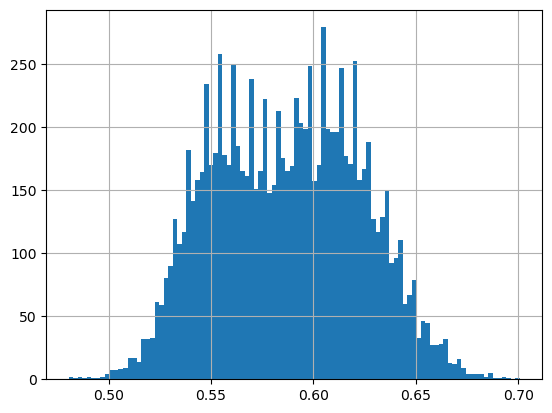

In [21]:
thermo["therm"].hist(bins=100)


<Axes: >

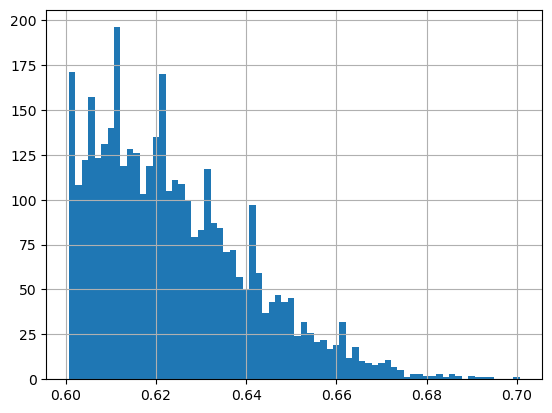

In [23]:
sel = thermo[thermo["therm"] > 0.6]
sel["therm"].hist(bins=70)